In [20]:
import numpy as np
import os
import tensorflow as tf
from matplotlib import pyplot as plt
import mediapipe as mp
import cv2
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense, Dropout, BatchNormalization,
                                     Bidirectional, Masking, LayerNormalization)
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
import tensorflow.keras.backend as K

In [4]:
# ─── Cấu hình dataset ─────────────────────────────────────────────────────────
DATA_PATH = r'C:\Users\PC\Documents\WorkSpace\KHOA_LUAN\LSTM\DATA-FINAL'

## 60 video dữ liệu
num_sequences = 100
#mỗi video dài 30 frame
sequence_length = 30

In [6]:
actions = np.array(['An','Ban','Bien','Binh Minh','Buoi Sang','Buoi Toi','Buon','Ca Phe','Cai Gi','Cam On','Cam Thay','Cua','Dau Dau','De Tai','Dep','Di',
                   'Gia Lai','Hoang Hon','Hoc','Hom Nay','Hom Qua','Khoe','Khong','Khong Muon','Khong Thich','Lo Lang','Mat','Met','Moi Nguoi','Mua','Muon','Nang','Ngam','Ngay Mai',
                   'Nghe','Nhac','Nhat Ban','Nhung','Nong','Quy Nhon','Song','Ten','Thay Co','Thich','Toi','Toi Thich Ban','Tom','Trinh Bay','Troi','Uong','Viet Nam','Vui','Xin Chao','Xin Loi'])

In [8]:
label_map = {label: num for num, label in enumerate(actions)}

In [11]:
label_map

{'An': 0,
 'Ban': 1,
 'Bien': 2,
 'Binh Minh': 3,
 'Buoi Sang': 4,
 'Buoi Toi': 5,
 'Buon': 6,
 'Ca Phe': 7,
 'Cai Gi': 8,
 'Cam On': 9,
 'Cam Thay': 10,
 'Cua': 11,
 'Dau Dau': 12,
 'De Tai': 13,
 'Dep': 14,
 'Di': 15,
 'Gia Lai': 16,
 'Hoang Hon': 17,
 'Hoc': 18,
 'Hom Nay': 19,
 'Hom Qua': 20,
 'Khoe': 21,
 'Khong': 22,
 'Khong Muon': 23,
 'Khong Thich': 24,
 'Lo Lang': 25,
 'Mat': 26,
 'Met': 27,
 'Moi Nguoi': 28,
 'Mua': 29,
 'Muon': 30,
 'Nang': 31,
 'Ngam': 32,
 'Ngay Mai': 33,
 'Nghe': 34,
 'Nhac': 35,
 'Nhat Ban': 36,
 'Nhung': 37,
 'Nong': 38,
 'Quy Nhon': 39,
 'Song': 40,
 'Ten': 41,
 'Thay Co': 42,
 'Thich': 43,
 'Toi': 44,
 'Toi Thich Ban': 45,
 'Tom': 46,
 'Trinh Bay': 47,
 'Troi': 48,
 'Uong': 49,
 'Viet Nam': 50,
 'Vui': 51,
 'Xin Chao': 52,
 'Xin Loi': 53}

In [15]:
sequences, labels= [], [] #Danh sách chứa toàn bộ dữ liệu video vvà nhãn
for action in actions:
    for sequence in range(num_sequences):
        window = []  #Lưu 30 frame của 1 video
        for frame_num in range(sequence_length):
            res = np.load(os.path.join(DATA_PATH,action, str(sequence), '{}.npy'.format(frame_num)))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

In [17]:
X = np.array(sequences, dtype=np.float32)
y = np.array(labels)

In [19]:
np.save('sequences.npy', X)
np.save('labels.npy', y)

In [10]:
X = np.load('sequences.npy')
y_int = np.load('labels.npy')

In [16]:
y_int = np.load('labels.npy')

In [22]:
y = to_categorical(y_int)

In [24]:
y

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)

In [21]:
X.shape

(5400, 30, 1662)

In [23]:
# ========================
# 1. Cắt pose + hands
# ========================
pose = X[:, :, 0:132]

lh = X[:, :, 1536:1599]
rh = X[:, :, 1599:1662]

# ========================
# 2. Face indices 
# ========================
#Viền mặt
idx_vien_mat = [
    10, 338, 297, 332, 284, 251, 389, 356,
    454, 323, 361, 288, 397, 365, 379, 378,
    400, 377, 152, 148, 176, 149, 150, 136,
    172, 58, 132, 93, 234, 127, 162, 21,
    54, 103, 67, 109
]

#Mắt
idx_mat_trai = [33,160,158,133,153,144,145,163,7,246,226,110, 24,23,22,26,112,243,190,56,28,27,29,30,247]
idx_mat_phai = [362,385,387,263,373,380,374,390,249,466,463,341,256,252,253,254,339,446,467,260,259,257,258,286,414]

#Lông mày
idx_long_may_trai = [70,63,105,66,107,55,65,52,53,46]
idx_long_may_phai = [336,296,334,293,300,276,283,282,295,285]

idx_mieng = [
    61,146,91,181,84,17,314,405,
    321,375,291,409,270,269,267,0,37,39,40,185,308,324,318,402,317,
    14,87,178,88,95,78,191,80,81,82,13,312,311,310,415
]

SELECTED_FACE_IDX = sorted(set(
    idx_vien_mat +
    idx_mat_trai + idx_mat_phai +
    idx_long_may_trai + idx_long_may_phai +
    idx_mieng
))

# ========================
# 3. Convert sang index trong X
# ========================
# Face bắt đầu từ index 132, mỗi điểm có 3 giá trị (x,y,z)

face_features = []

for idx in SELECTED_FACE_IDX:
    start = 132 + idx * 3
    face_features.extend([start, start+1, start+2])

face_features = np.array(face_features)
# ========================
# 4. Extract face subset
# ========================
face = X[:, :, face_features]

# ========================
# 5. Concatenate lại
# ========================
X_new = np.concatenate([pose, face, lh, rh], axis=2)

print("Shape sau cắt:", X_new.shape)

# ========================
# 6. Save
# ========================
np.save('sequences_selected.npy', X_new)

Shape sau cắt: (5400, 30, 696)


In [26]:
X = np.load('sequences_selected.npy')

In [35]:
X.shape

(5400, 30, 696)

In [28]:
def standardize_keypoints(X_data):
    X_cent = X_data.copy()
    is_2d = False
    if len(X_cent.shape) == 2:
        is_2d = True
        X_cent = np.expand_dims(X_cent, axis=0) 
        
    # --- 1. Nội suy 2 chiều (Tiến và Lùi) để sạch bóng giá trị 0 ---
    for b in range(X_cent.shape[0]):
        # Tiến (Forward fill)
        for t in range(1, X_cent.shape[1]):
            zeros_mask = (X_cent[b, t, :] == 0.0)
            X_cent[b, t, zeros_mask] = X_cent[b, t-1, zeros_mask]
        # Lùi (Backward fill - xử lý nốt nếu frame 0 bị lỗi)
        for t in range(X_cent.shape[1]-2, -1, -1):
            zeros_mask = (X_cent[b, t, :] == 0.0)
            X_cent[b, t, zeros_mask] = X_cent[b, t+1, zeros_mask]
            
    # --- 2. Chống rung EMA ---
    alpha = 0.6  
    for b in range(X_cent.shape[0]):
        for t in range(1, X_cent.shape[1]):
            X_cent[b, t, :] = alpha * X_cent[b, t, :] + (1 - alpha) * X_cent[b, t-1, :]
            
    # --- 3. Centering an toàn (Neo điểm) ---
    nose_x = X_cent[:, :, 0:1].copy()
    nose_y = X_cent[:, :, 1:2].copy()
    nose_z = X_cent[:, :, 2:3].copy()
    
    # Dự phòng: Nếu mũi Pose bị 0, dùng mũi của Face (index 132)
    mask_zero = (nose_x == 0)
    nose_x[mask_zero] = X_cent[:, :, 132:133][mask_zero]
    nose_y[mask_zero] = X_cent[:, :, 133:134][mask_zero]
    nose_z[mask_zero] = X_cent[:, :, 134:135][mask_zero]
    
    X_cent[:, :, 0:132:4] -= nose_x
    X_cent[:, :, 1:132:4] -= nose_y
    X_cent[:, :, 2:132:4] -= nose_z
    X_cent[:, :, 132::3] -= nose_x
    X_cent[:, :, 133::3] -= nose_y
    X_cent[:, :, 134::3] -= nose_z
   
    return X_cent


X = np.load('sequences_selected.npy', allow_pickle=True)
print("Shape ban đầu:", X.shape)
X = standardize_keypoints(X)
print("Shape sau chuẩn hóa:", X.shape)

Shape ban đầu: (5400, 30, 696)
Shape sau chuẩn hóa: (5400, 30, 696)


In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42,stratify=y_int)

In [38]:
X_train.shape

(4590, 30, 696)

In [40]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.176, 
    random_state=42,
    stratify=y_train.argmax(axis=1)  
)

In [45]:
X_train.shape

(3782, 30, 696)

In [ ]:
#**Các kĩ thuật tăng cường dữ liệu**

In [42]:
def augment_sequence(seq):
    aug = seq.copy()
    zero_mask = (seq == 0.0)

    
    # Trả các khoảng trống về lại đúng 0.0
    aug[zero_mask] = 0.0

    
    # 1. Gaussian Noise
    if np.random.rand() < 0.5:
        aug += np.random.normal(0, 0.012, aug.shape)

    # 2. Time Shift
    if np.random.rand() < 0.5:
        shift = np.random.randint(-4, 5)
        if shift > 0:
            aug[shift:] = aug[:-shift]
            aug[:shift] = 0.0
        elif shift < 0:
            aug[:shift] = aug[-shift:]
            aug[shift:] = 0.0

    # 3. Scaling
    if np.random.rand() < 0.5:
        scale = np.random.uniform(0.9, 1.1)
        aug = aug * scale

    # 4.Speed Perturbation ±10%
    if np.random.rand() < 0.3:
        speed = np.random.uniform(0.9, 1.1)
        T = aug.shape[0]  # = 30
        new_len = max(1, int(T / speed))
        idx = np.linspace(0, T - 1, new_len).astype(int)
        idx = np.clip(idx, 0, T - 1)
        aug_resampled = aug[idx]
        resample_idx = np.linspace(0, len(aug_resampled) - 1, T).astype(int)
        aug = aug_resampled[resample_idx]

    # 5.I: Random Joint Masking (mô phỏng webcam mất tracking)
    if np.random.rand() < 0.2:
        mask_start = np.random.randint(0, 25)
        mask_len = np.random.randint(3, 6)
        n_features = aug.shape[1]
        mask_features = np.random.choice(
            n_features, size=int(n_features * 0.15), replace=False
        )
        aug[mask_start:mask_start + mask_len, mask_features] = 0.0

    # Trả các khoảng trống về lại đúng 0.0
    aug[zero_mask] = 0.0

    return aug.astype(np.float32)


In [ ]:
**Tạo thêm dữ liệu giả (augment) từ dữ liệu gốc**

In [44]:
def build_augmented_dataset(X, y, n_aug=4):
    X_list = [X.astype(np.float32)]
    y_list = [y]
    for _ in range(n_aug):
        X_list.append(np.array([augment_sequence(x) for x in X], dtype=np.float32))
        y_list.append(y)
    X_aug = np.concatenate(X_list)
    y_aug = np.concatenate(y_list)
    perm  = np.random.permutation(len(X_aug))
    return X_aug[perm], y_aug[perm]

In [46]:
X_train_aug, y_train_aug = build_augmented_dataset(X_train, y_train, n_aug=4)
print(f"Train sau augment: {X_train_aug.shape}")

Train sau augment: (18910, 30, 696)


In [53]:
# Shuffle lại sau augment
perm = np.random.permutation(len(X_train_aug))
X_train_aug, y_train_aug = X_train_aug[perm], y_train_aug[perm]

In [55]:
X_train_aug.shape

(18910, 30, 696)

In [57]:
# Chuẩn hóa input VỀ mean ~ VÀ std ~ 1 -> Giúp model học ổn định và nhanh hơn
#Giúp model học ổn định và nhanh hơn
# Fit scaler chỉ trên train, transform cả train + test
mean = X_train_aug.mean(axis=(0,1), keepdims=True)
std  = X_train_aug.std(axis=(0,1),  keepdims=True) + 1e-8

X_train_norm = (X_train_aug - mean) / std
X_test_norm  = (X_test  - mean) / std
X_val_norm   = (X_val  - mean) / std

X_train_norm[X_train_aug == 0.0] = 0.0
X_test_norm[X_test == 0.0] = 0.0
X_val_norm[X_val == 0.0] = 0.0

np.save('norm_mean.npy', mean.squeeze())
np.save('norm_std.npy',  std.squeeze())


In [48]:
mean = np.load("norm_mean.npy").squeeze()
std  = np.load("norm_std.npy").squeeze()

In [50]:
X_train_norm = (X_train_aug - mean) / std
X_test_norm  = (X_test  - mean) / std
X_val_norm   = (X_val  - mean) / std

X_train_norm[X_train_aug == 0.0] = 0.0
X_test_norm[X_test == 0.0] = 0.0
X_val_norm[X_val == 0.0] = 0.0

In [63]:
num_classes = y.shape[1]
model = Sequential([
    LayerNormalization(input_shape=(30, 696)), 
    
    LSTM(256, return_sequences=True, activation='tanh', recurrent_dropout=0.25),
    BatchNormalization(),
    Dropout(0.45),

    LSTM(128, return_sequences=False, activation='tanh', recurrent_dropout=0.25),
    BatchNormalization(),
    Dropout(0.45),

    Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.008)),
    Dropout(0.35),

    Dense(num_classes, activation='softmax')
])


In [65]:
initial_lr   = 0.001
decay_steps  = 5000
lr_schedule  = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=initial_lr,
    first_decay_steps=decay_steps,
    t_mul=2.0, m_mul=0.9, alpha=1e-5
)

optimizer = Adam(learning_rate=lr_schedule)
loss      = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)  # 0.1→0.05

model.compile(optimizer=optimizer, loss=loss, metrics=['categorical_accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 layer_normalization (Layer  (None, 30, 696)           1392      
 Normalization)                                                  
                                                                 
 lstm (LSTM)                 (None, 30, 256)           975872    
                                                                 
 batch_normalization (Batch  (None, 30, 256)           1024      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 30, 256)           0         
                                                                 
 lstm_1 (LSTM)               (None, 128)               197120    
                                                                 
 batch_normalization_1 (Bat  (None, 128)               5

In [67]:
# ─── Callbacks ────────────────────────────────────────────────────────────────
log_dir = os.path.join('Logs')
callbacks = [
    TensorBoard(log_dir=log_dir),
    EarlyStopping(
        monitor='val_loss',
        patience=30,
        restore_best_weights=True,
        mode='min',
        verbose=1
    ),
    #Lưu model tốt nhất
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    )
]

In [69]:
model.fit(
    X_train_norm, y_train_aug,
    epochs=1000,
    batch_size=32,                          
    validation_data=(X_val_norm, y_val),   
    callbacks=callbacks,       
)

Epoch 1/1000


591/591 [==============================] - ETA: 0s - loss: 3.3045 - categorical_accuracy: 0.4137
Epoch 1: val_loss improved from inf to 1.92156, saving model to best_model.keras
591/591 [==============================] - 210s 314ms/step - loss: 3.3045 - categorical_accuracy: 0.4137 - val_loss: 1.9216 - val_categorical_accuracy: 0.7475
Epoch 2/1000
591/591 [==============================] - ETA: 0s - loss: 1.7815 - categorical_accuracy: 0.7720
Epoch 2: val_loss improved from 1.92156 to 1.38472, saving model to best_model.keras
591/591 [==============================] - 200s 338ms/step - loss: 1.7815 - categorical_accuracy: 0.7720 - val_loss: 1.3847 - val_categorical_accuracy: 0.8700
Epoch 3/1000
591/591 [==============================] - ETA: 0s - loss: 1.3544 - categorical_accuracy: 0.8841
Epoch 3: val_loss improved from 1.38472 to 1.15606, saving model to best_model.keras
591/591 [==============================] - 179s 302ms/step - loss: 1.3544 - categorical_accuracy: 0

In [52]:
import numpy as np
from tensorflow.keras.models import load_model

model = load_model("best_model.keras")

val_loss, val_acc = model.evaluate(X_test_norm, y_test, verbose=0)
print(f"Độ chính xác: {val_acc*100:.1f}%")



Độ chính xác: 98.0%


In [54]:
import numpy as np
from tensorflow.keras.models import load_model

model = load_model("best_model.keras")

val_loss, val_acc = model.evaluate(X_test_norm, y_test, verbose=0)
print(f"Độ chính xác: {val_acc*100:.1f}%")

Độ chính xác: 98.0%


In [56]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_pred = model.predict(X_test_norm)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

precision = precision_score(y_true_classes, y_pred_classes, average='weighted')
recall    = recall_score(y_true_classes, y_pred_classes, average='weighted')
f1        = f1_score(y_true_classes, y_pred_classes, average='weighted')

print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"F1-Score:  {f1*100:.2f}%")


26/26 [==============================] - 3s 79ms/step
Precision: 98.07%
Recall:    98.02%
F1-Score:  98.01%


In [58]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Dự đoán
y_pred = model.predict(X_test_norm)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# In báo cáo chi tiết từng lớp
print(classification_report(y_true_classes, y_pred_classes, target_names=actions))


26/26 [==============================] - 2s 93ms/step
               precision    recall  f1-score   support

           An       1.00      1.00      1.00        15
          Ban       1.00      1.00      1.00        15
         Bien       1.00      0.93      0.97        15
    Binh Minh       1.00      1.00      1.00        15
    Buoi Sang       0.94      1.00      0.97        15
     Buoi Toi       1.00      1.00      1.00        15
         Buon       1.00      1.00      1.00        15
       Ca Phe       1.00      1.00      1.00        15
       Cai Gi       1.00      1.00      1.00        15
       Cam On       1.00      1.00      1.00        15
     Cam Thay       1.00      1.00      1.00        15
          Cua       0.88      0.93      0.90        15
      Dau Dau       1.00      1.00      1.00        15
       De Tai       1.00      1.00      1.00        15
          Dep       0.94      1.00      0.97        15
           Di       1.00      1.00      1.00        15
      Gia 

In [60]:
# ========================
# 2. Hàm select keypoints
# ========================
def extract_selected_keypoints(X):
    pose = X[:, 0:132]
    lh = X[:, 1536:1599]
    rh = X[:, 1599:1662]

    idx_vien_mat = [
        10,338,297,332,284,251,389,356,454,323,361,288,
        397,365,379,378,400,377,152,148,176,149,150,136,
        172,58,132,93,234,127,162,21,54,103,67,109
    ]

    idx_mat_trai = [33,160,158,133,153,144,145,163,7,246,226,110,24,23,22,26,112,243,190,56,28,27,29,30,247]
    idx_mat_phai = [362,385,387,263,373,380,374,390,249,466,463,341,256,252,253,254,339,446,467,260,259,257,258,286,414]

    idx_long_may_trai = [70,63,105,66,107,55,65,52,53,46]
    idx_long_may_phai = [336,296,334,293,300,276,283,282,295,285]

    idx_mieng = [
        61,146,91,181,84,17,314,405,
        321,375,291,409,270,269,267,0,37,39,40,185,
        308,324,318,402,317,14,87,178,88,95,78,191,
        80,81,82,13,312,311,310,415
    ]

    SELECTED_FACE_IDX = sorted(set(
        idx_vien_mat +
        idx_mat_trai + idx_mat_phai +
        idx_long_may_trai + idx_long_may_phai +
        idx_mieng
    ))

    face_features = []
    for idx in SELECTED_FACE_IDX:
        start = 132 + idx * 3
        face_features.extend([start, start+1, start+2])

    face_features = np.array(face_features)

    face = X[:, face_features]

    X_new = np.concatenate([pose, face, lh, rh], axis=1)

    return X_new.astype(np.float32)


In [76]:
from tensorflow.keras.models import load_model
import tensorflow as tf
import numpy as np
import os
# (Bạn có thể đổi tên thư mục chữa 30 file .npy ở đây)
TEST_FOLDER = "Uong" 
print("Loading model and weights...")
model = tf.keras.models.load_model('best_model.keras')
mean = np.load("norm_mean.npy").squeeze()
std  = np.load("norm_std.npy").squeeze()
print(f"Reading 30 frames from folder '{TEST_FOLDER}'...")
files = sorted(os.listdir(TEST_FOLDER), key=lambda x: int(x.split('.')[0]))
frames = [np.load(os.path.join(TEST_FOLDER, f)) for f in files]
# Chuyển list NPY thành mảng Numpy nguyên khối 
X = np.array(frames)
if X.shape != (30, 1662):
    print(f"⚠️ Cảnh báo: File trong thư mục đang có cỡ {X.shape}. Code mong đợi cỡ (30, 1662).")
# Dây chuyền chuẩn hóa đầu vào theo đúng sách giáo khoa:
X = extract_selected_keypoints(X)   # Bước 1: Gọt dũa rút gọn (30, 1662 -> 30, 696)
X = standardize_keypoints(X)        # Bước 2: Kéo cự ly và Không gian về gốc tỷ lệ 
X = (X - mean) / std                # Bước 3: Dập khuôn số học Z-Score     # Bước 4: Tạo chiều Batch (Thêm gói ngoài cùng thành 1, 30, 696)
# Kích hoạt Model tính tỷ lệ hành động
print("\nPredicting...")
y_pred = model.predict(X)[0] # Lấy list 50 tỷ lệ phần trăm phân bổ
# Trích xuất 3 kết quả tự tin nhất của Model
print("\n==============================")
print("     KẾT QUẢ NHẬN DIỆN        ")
print("==============================")
top_3_indices = np.argsort(y_pred)[-3:][::-1]
for i, index in enumerate(top_3_indices):
    label = actions[index]
    prob = y_pred[index] * 100
    if i == 0:
        print(f"⭐ [TOP 1] Hành động dự đoán: '{label}' (Khớp {prob:.2f}%)")
    else:
        print(f"   [Top {i+1}] Gợi ý thêm: '{label}' (Khớp {prob:.2f}%)")

Loading model and weights...
Reading 30 frames from folder 'Uong'...

Predicting...
1/1 [==============================] - 1s 843ms/step

     KẾT QUẢ NHẬN DIỆN        
⭐ [TOP 1] Hành động dự đoán: 'Uong' (Khớp 95.45%)
   [Top 2] Gợi ý thêm: 'An' (Khớp 0.31%)
   [Top 3] Gợi ý thêm: 'Toi Thich Ban' (Khớp 0.19%)


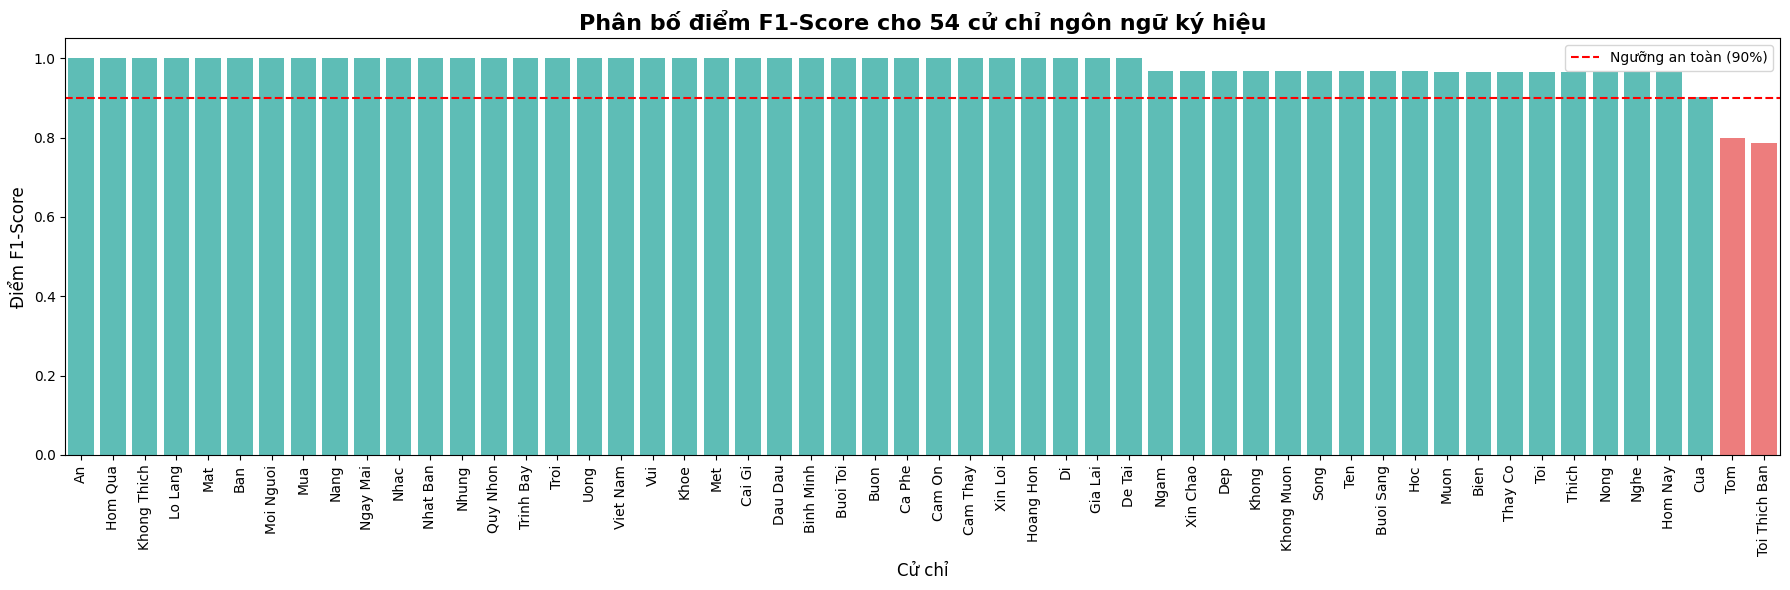

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# Lấy dữ liệu dạng Dictionary thay vì Text
report_dict = classification_report(y_true_classes, y_pred_classes, target_names=actions, output_dict=True)

# Lọc ra F1-score của 50 nhãn
f1_scores = {label: metrics['f1-score'] for label, metrics in report_dict.items() if label in actions}

# Chuyển thành DataFrame và sắp xếp giảm dần
df_f1 = pd.DataFrame(list(f1_scores.items()), columns=['Từ vựng', 'F1-Score'])
df_f1 = df_f1.sort_values(by='F1-Score', ascending=False)

# Cấu hình vẽ biểu đồ
plt.figure(figsize=(18, 6))
# Những cột điểm thấp (< 0.9) sẽ có màu đỏ nổi bật, còn lại màu xanh
colors = ['#ff6b6b' if score < 0.9 else '#4ecdc4' for score in df_f1['F1-Score']]
sns.barplot(
    x='Từ vựng',
    y='F1-Score',
    data=df_f1,
    hue='Từ vựng',
    palette=colors,
    dodge=False,
    legend=False
)

plt.title('Phân bố điểm F1-Score cho 54 cử chỉ ngôn ngữ ký hiệu', fontsize=16, fontweight='bold')
plt.ylabel('Điểm F1-Score', fontsize=12)
plt.xlabel('Cử chỉ', fontsize=12)
plt.xticks(rotation=90)
plt.axhline(y=0.9, color='red', linestyle='--', linewidth=1.5, label='Ngưỡng an toàn (90%)')
plt.ylim(0, 1.05)
plt.legend()

# Lưu ảnh nét cao để chèn vào báo cáo
plt.tight_layout()
plt.savefig('f1_score_chart.png', dpi=300)
plt.show()


26/26 [==============================] - 3s 69ms/step


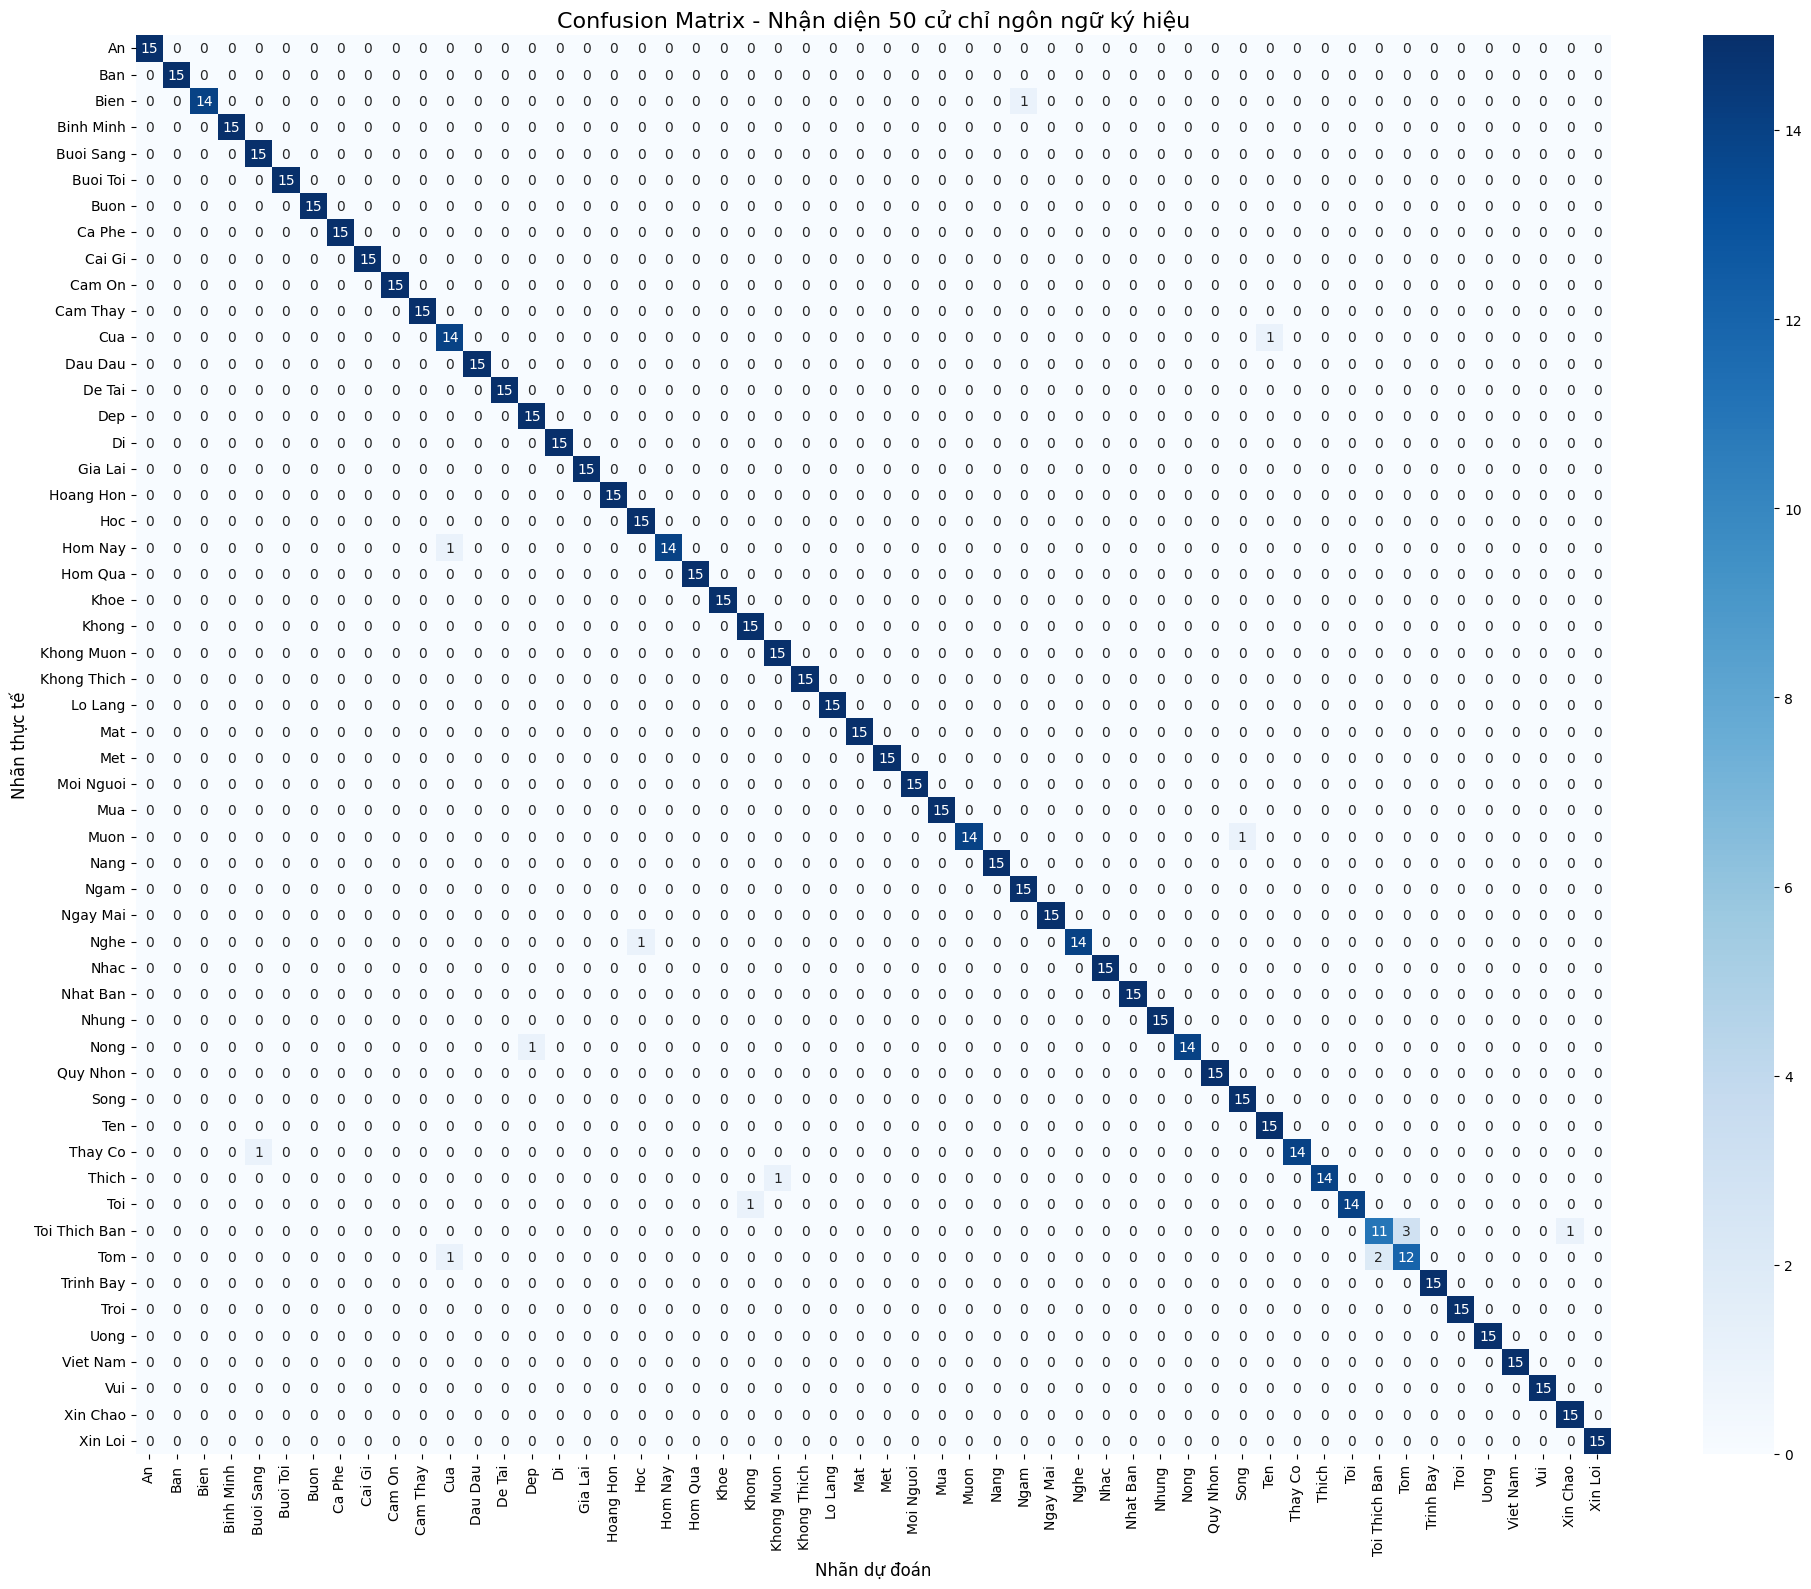


Tổng số mẫu test: 810
Số mẫu dự đoán sai: 16
Tỷ lệ sai: 1.98%


In [86]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model

# 1. Load mô hình tốt nhất (đã lưu khi huấn luyện)
model = load_model("best_model.keras")

# 2. Dự đoán trên tập test
y_pred = model.predict(X_test_norm)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# 3. Tính confusion matrix (không chuẩn hóa)
cm = confusion_matrix(y_true_classes, y_pred_classes)

# 4. Vẽ heatmap
plt.figure(figsize=(20, 16))  # kích thước lớn vì có 50 lớp
sns.heatmap(cm, 
            annot=True,          # hiển thị số
            fmt='d',             # số nguyên
            cmap='Blues',        # màu sắc
            xticklabels=actions, # nhãn dự đoán
            yticklabels=actions) # nhãn thật
plt.title('Confusion Matrix - Nhận diện 50 cử chỉ ngôn ngữ ký hiệu', fontsize=16)
plt.xlabel('Nhãn dự đoán', fontsize=12)
plt.ylabel('Nhãn thực tế', fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# (Tuỳ chọn) In ra tổng số lượng dự đoán sai
misclassified = np.sum(y_true_classes != y_pred_classes)
print(f"\nTổng số mẫu test: {len(y_true_classes)}")
print(f"Số mẫu dự đoán sai: {misclassified}")
print(f"Tỷ lệ sai: {misclassified/len(y_true_classes)*100:.2f}%")

In [88]:
import pandas as pd

# Tạo DataFrame từ confusion matrix
cm_df = pd.DataFrame(cm, index=actions, columns=actions)

# Lọc những ô ngoài đường chéo có giá trị > 0
misclass_table = []
for i, true_label in enumerate(actions):
    for j, pred_label in enumerate(actions):
        if i != j and cm[i, j] > 0:
            misclass_table.append([true_label, pred_label, cm[i, j]])

df_mis = pd.DataFrame(misclass_table, columns=['True Label', 'Predicted Label', 'Count'])
df_mis = df_mis.sort_values('Count', ascending=False)

# (Tuỳ chọn) In ra tổng số lượng dự đoán sai
misclassified = np.sum(y_true_classes != y_pred_classes)
print(f"\nTổng số mẫu test: {len(y_true_classes)}")
print(f"Số mẫu dự đoán sai: {misclassified}")
print(f"Tỷ lệ sai: {misclassified/len(y_true_classes)*100:.2f}%")
print()
print("Các cặp nhầm lẫn (True → Predicted):")
print(df_mis.to_string(index=False))


Tổng số mẫu test: 810
Số mẫu dự đoán sai: 16
Tỷ lệ sai: 1.98%

Các cặp nhầm lẫn (True → Predicted):
   True Label Predicted Label  Count
Toi Thich Ban             Tom      3
          Tom   Toi Thich Ban      2
         Bien            Ngam      1
          Cua             Ten      1
      Hom Nay             Cua      1
         Muon            Song      1
         Nghe             Hoc      1
         Nong             Dep      1
      Thay Co       Buoi Sang      1
        Thich      Khong Muon      1
          Toi           Khong      1
Toi Thich Ban        Xin Chao      1
          Tom             Cua      1
